<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####**B4. Implement the K-Means algorithm and visualize the data in 2-D space before clustering. Compare the performance of the K-means clustering algorithm with the DBSCAN algorithm.**

####**K-Means Clustering**


K-Means is a partition-based clustering algorithm that divides data into $K$ clusters by minimizing the within-cluster sum of squared distances between data points and their corresponding cluster centroids.

Key Definitions and Formulas

1. Number of Clusters
$
K \in \mathbb{N}
$

2. Cluster Assignment
Each data point $x_i$ is assigned to the nearest centroid:
$
c_i = \arg\min_{k \in \{1,\dots,K\}} \| x_i - \mu_k \|^2
$

3. Centroid Update
The centroid of cluster $k$ is the mean of all points assigned to it:
$
\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i
$

4. Objective Function (Within-Cluster Sum of Squares)
$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$

5. Distance Measure (Euclidean)
$
\| x_i - \mu_k \|^2 = \sum_{j=1}^{d} (x_{ij} - \mu_{kj})^2
$

6. Convergence Condition
K-Means converges when:
$
C_k^{(t)} = C_k^{(t-1)} \quad \forall k
$

K-Means iteratively minimizes the within-cluster variance by alternating between cluster assignment and centroid update, producing spherical and well-separated clusters.

####**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**


DBSCAN is a density-based clustering algorithm that groups points lying in high-density regions and labels points in low-density regions as noise, without requiring the number of clusters in advance.


1. $\varepsilon$-Neighborhood
$
N_\varepsilon(p) = \{\, q \in D \mid \text{dist}(p,q) \le \varepsilon \,\}
$

2. Core Point
A point $p$ is a core point if:
$
|N_\varepsilon(p)| \ge \text{MinPts}
$

3. Border Point
A point $q$ is a border point if:
$
|N_\varepsilon(q)| < \text{MinPts}
\quad \text{and} \quad
\exists\, p \text{ such that } q \in N_\varepsilon(p)
$

4. Noise Point
$
p \notin \text{any cluster}
$

5. Directly Density-Reachable}\
A point $q$ is directly density-reachable from $p$ if:
$
q \in N_\varepsilon(p)
\quad \text{and} \quad
|N_\varepsilon(p)| \ge \text{MinPts}
$

6. Density-Reachable
A point $q$ is density-reachable from $p$ if there exists a sequence:
$
p = p_1, p_2, \dots, p_n = q
$
such that $p_{i+1}$ is directly density-reachable from $p_i$.

7. Density-Connected
Two points $p$ and $q$ are density-connected if:
$
\exists\, o \in D \text{ such that } p \text{ and } q \text{ are density-reachable from } o
$

8. Cluster Definition
A DBSCAN cluster $C$ is defined as:
$
C = \{\, p \mid p \text{ is density-connected} \,\}
$

9. Distance Measure (Euclidean)
$
\text{dist}(p,q) = \sqrt{\sum_{i=1}^{d}(p_i - q_i)^2}
$


DBSCAN forms clusters by connecting density-reachable points using parameters $\varepsilon$ and MinPts, allowing detection of arbitrary-shaped clusters and explicit identification of noise.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Create three clusters
cluster_1 = np.random.randn(100, 2) + np.array([2, 2])
cluster_2 = np.random.randn(100, 2) + np.array([-2, -2])
cluster_3 = np.random.randn(100, 2) + np.array([2, -2])

# Create noise
noise = np.random.uniform(low=-5, high=5, size=(30, 2))

# Combine all points
X = np.vstack((cluster_1, cluster_2, cluster_3, noise))


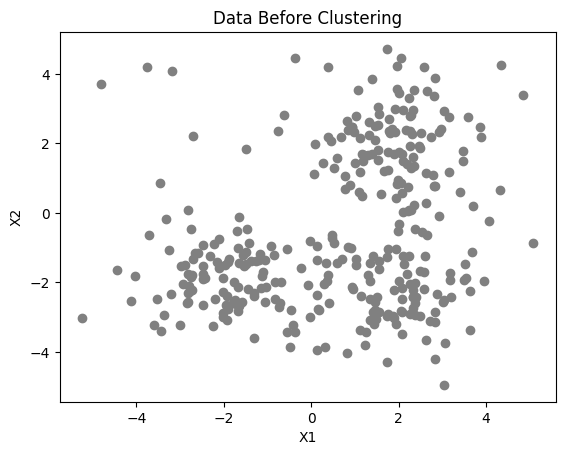

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c='gray')
plt.title("Data Before Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


##**K--Means Clustering Implementation**

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


In [ ]:


class KMeans:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        # Randomly select k data points as initial centroids
        self.centroids = X[np.random.choice(len(X), self.k, replace=False)]

        for _ in range(self.max_iters):
            clusters = [[] for _ in range(self.k)]

            # Assign points to nearest centroid
            for point in X:
                distances = [
                    np.sqrt(np.sum((point - centroid) ** 2))
                    for centroid in self.centroids
                ]
                cluster_index = np.argmin(distances)
                clusters[cluster_index].append(point)

            # Update centroids
            new_centroids = [
                np.mean(cluster, axis=0)
                for cluster in clusters
            ]

            # Check convergence
            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

    def predict(self, X):
        labels = []

###**Predict Method**

In [ ]:
    def predict(self, X):
        labels = []
        for point in X:
            distances = [euclidean_distance(point, centroid) for centroid in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)

####**Run K-means**

In [ ]:
kmeans = KMeans(k=3)
kmeans.fit(X)
kmeans_labels = kmeans.predict(X)

/tmp/ipython-input-750301685.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')


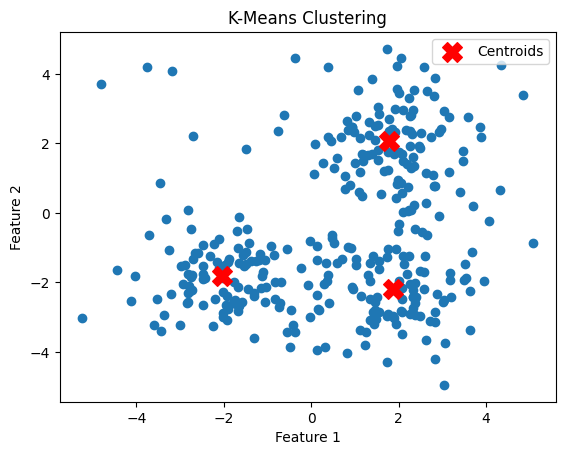

In [ ]:

plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.scatter(np.array(kmeans.centroids)[:,0], np.array(kmeans.centroids)[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

##**DBSCAN Implementation**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters found:", n_clusters)

Number of clusters found: 1


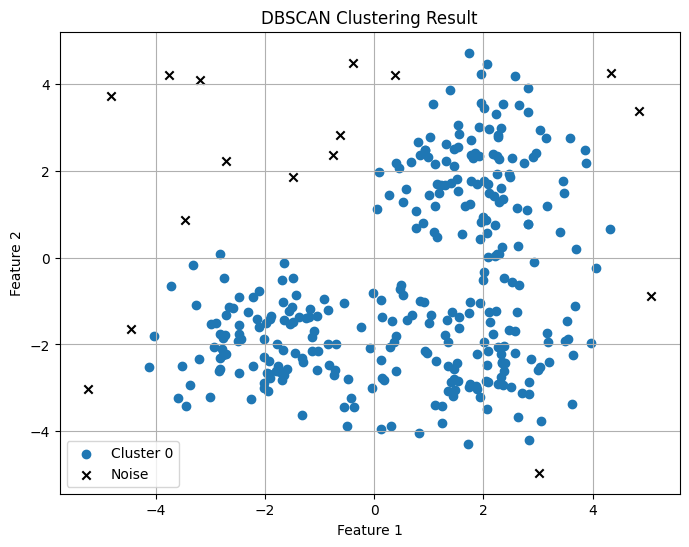

In [ ]:
plt.figure(figsize=(8, 6))

# Plot clusters
unique_labels = set(labels)
for label in unique_labels:
    if label == -1:
        # Noise points
        plt.scatter(
            X[labels == label, 0],
            X[labels == label, 1],
            c="black",
            marker="x",
            label="Noise"
        )
    else:
        plt.scatter(
            X[labels == label, 0],
            X[labels == label, 1],
            label=f"Cluster {label}"
        )
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()